In [25]:
import numpy as np
import time
import matplotlib.pyplot as plt

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            return x_new, k, errors

        x = x_new

    return x, max_iterations, errors


def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i+1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            return x_new, k, errors

        x = x_new

    return x, max_iterations, errors

In [20]:
A = np.array([[3, -0.1, -0.2], 
              [0.1, 7, -0.3], 
              [0.3, -0.2, 10], ], dtype=float)
b = np.array([7.85, -19.3, 71.4], dtype=float)

In [26]:
tol = 1e-3
max_iterations = 100
x0 = np.zeros_like(b, dtype=float)

startg = time.perf_counter()
solution_g, iterations_g, errors_g = gauss_seidel(A, b, x0, tol, max_iterations)
endg = time.perf_counter()
startj = time.perf_counter()
solution_j, iterations_j, errors_j = jacobi(A, b, x0, tol, max_iterations)
endj=time.perf_counter()
print("gauss seidel: ", str(iterations_g), " tries")
print("time: ", str(endg-startg))
print(solution_g)
print("jacobi: ", str(iterations_j), " tries")
print("time: ", str(endj-startj))
print(solution_j)

gauss seidel:  3  tries
time:  0.0008549760095775127
[ 3.00000035 -2.50000004  6.99999999]
jacobi:  3  tries
time:  0.000729820691049099
[ 3.0000225  -2.50000266  6.99998104]


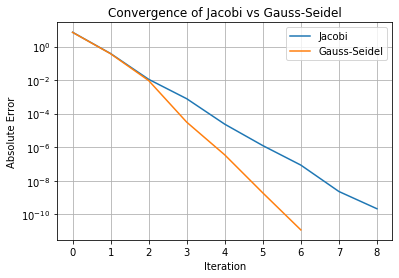

In [35]:
plt.semilogy(errors_j, label="Jacobi")
plt.semilogy(errors_g, label="Gauss-Seidel")

plt.xlabel("Iteration")
plt.ylabel("Absolute Error")
plt.title("Convergence of Jacobi vs Gauss-Seidel")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
tol = 1e-6
max_iterations = 100
x0 = np.zeros_like(b, dtype=float)

startg = time.perf_counter()
solution_g, iterations_g, errors_g = gauss_seidel(A, b, x0, tol, max_iterations)
endg = time.perf_counter()
startj = time.perf_counter()
solution_j, iterations_j, errors_j = jacobi(A, b, x0, tol, max_iterations)
endj=time.perf_counter()
print("gauss seidel: ", str(iterations_g), " tries")
print("time: ", str(endg-startg))
print(solution_g)
print("jacobi: ", str(iterations_j), " tries")
print("time: ", str(endj-startj))
print(solution_j)

gauss seidel:  4  tries
time:  0.000497882254421711
[ 3.  -2.5  7. ]
jacobi:  6  tries
time:  0.0004985202103853226
[ 3.  -2.5  7. ]


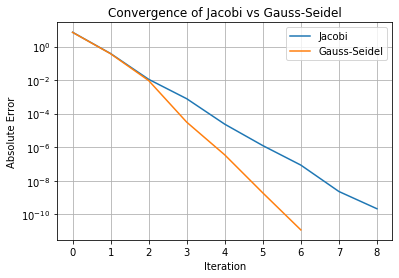

In [34]:
plt.semilogy(errors_j, label="Jacobi")
plt.semilogy(errors_g, label="Gauss-Seidel")

plt.xlabel("Iteration")
plt.ylabel("Absolute Error")
plt.title("Convergence of Jacobi vs Gauss-Seidel")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
tol = 1e-9
max_iterations = 100
x0 = np.zeros_like(b, dtype=float)

startg = time.perf_counter()
solution_g, iterations_g, errors_g = gauss_seidel(A, b, x0, tol, max_iterations)
endg = time.perf_counter()
startj = time.perf_counter()
solution_j, iterations_j, errors_j = jacobi(A, b, x0, tol, max_iterations)
endj=time.perf_counter()
print("gauss seidel: ", str(iterations_g), " tries")
print("time: ", str(endg-startg))
print(solution_g)
print("jacobi: ", str(iterations_j), " tries")
print("time: ", str(endj-startj))
print(solution_j)

gauss seidel:  6  tries
time:  0.0006862189620733261
[ 3.  -2.5  7. ]
jacobi:  8  tries
time:  0.000577232800424099
[ 3.  -2.5  7. ]


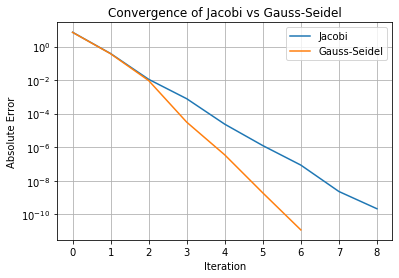

In [33]:
plt.semilogy(errors_j, label="Jacobi")
plt.semilogy(errors_g, label="Gauss-Seidel")

plt.xlabel("Iteration")
plt.ylabel("Absolute Error")
plt.title("Convergence of Jacobi vs Gauss-Seidel")
plt.legend()
plt.grid(True)
plt.show()

The tolerance determines how accurate our answer is by defining what difference between the iterations deems the function as done running. The smaller the function is, the more iterations the function needs to run. Smaller tolerance results in a faster function runtime and less iterations, whereass larger tolerance is higher runtime and more iterations. 